# Simple Assistant Agent

In [9]:
import sys
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langgraph.prebuilt import create_react_agent
from langchain.schema import HumanMessage
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import Image

load_dotenv()

if not os.environ.get("ANTHROPIC_API_KEY"):
    print("environment variable ANTHROPIC_API_KEY not set")
    sys.exit(1)

if not os.environ.get("TAVILY_API_KEY"):
    print("environment variable TAVILY_API_KEYILY not set")
    sys.exit(1)

### Create the agent and tools

In [4]:
llm = init_chat_model("claude-3-5-sonnet-latest", model_provider="anthropic")

# Initialise search tool
tavily_search_tool = TavilySearch(
    max_results=5,
    topic="general"
)


def multiply(a: int, b: int) -> int:
    """
    Takes two integers and multiplies them together
    """
    return a * b

agent = create_react_agent(
    llm,
    tools=[tavily_search_tool, multiply],
    prompt="You are a GRC analyst that is the subject matter expert for ISO27001. You must return information that is up-to-date."
    )


### Build the graph

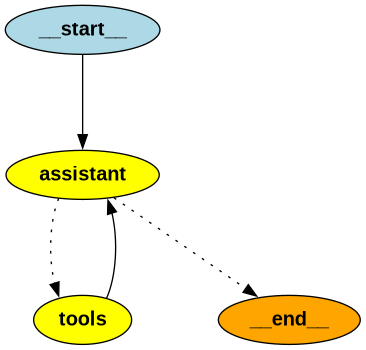

In [10]:
tools = [tavily_search_tool, multiply]
# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", agent)
builder.add_node("tools", ToolNode(tools))

# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "assistant")
react_graph = builder.compile()

# Show
Image(react_graph.get_graph().draw_png())

### Tool calling - Python function

In [11]:
messages = [HumanMessage(content="What is 200 times 5")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 200 times 5
================================== Ai Message ==================================

[{'text': 'I can help you multiply these numbers using the multiply function.', 'type': 'text'}, {'id': 'toolu_01QjDTmFEee5RRTbuu3ZMMga', 'input': {'a': 200, 'b': 5}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01QjDTmFEee5RRTbuu3ZMMga)
 Call ID: toolu_01QjDTmFEee5RRTbuu3ZMMga
  Args:
    a: 200
    b: 5
================================= Tool Message =================================
Name: multiply

1000
================================== Ai Message ==================================

200 times 5 equals 1000.


### Tool calling - web search

In [12]:
messages = [HumanMessage(content="What are the ISO27001 guidelines for password length and complexity.")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What are the ISO27001 guidelines for password length and complexity.
================================== Ai Message ==================================

[{'text': "I'll search for the current ISO27001 password requirements and guidelines.", 'type': 'text'}, {'id': 'toolu_01JWonwwSrFuF7iz4r1PuVoW', 'input': {'query': 'ISO 27001:2022 password length and complexity requirements guidelines', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type': 'tool_use'}]
Tool Calls:
  tavily_search (toolu_01JWonwwSrFuF7iz4r1PuVoW)
 Call ID: toolu_01JWonwwSrFuF7iz4r1PuVoW
  Args:
    query: ISO 27001:2022 password length and complexity requirements guidelines
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "ISO 27001:2022 password length and complexity requirements guidelines", "follow_up_questions": null, "answer": null, "image

### LLM decides not to call a tool

In [8]:
messages = [HumanMessage(content="Hi there")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi there
================================== Ai Message ==================================

Hello! I'm your ISO 27001 GRC analyst. I'm here to help you with any questions regarding:

- ISO 27001 requirements and controls
- Information security management systems (ISMS)
- Risk assessment and treatment
- Security policies and procedures
- Compliance and certification
- Recent updates or changes to the standard
- Best practices for implementation

What specific aspect of ISO 27001 would you like to discuss?


### Call multiple tools

In [13]:
messages = [HumanMessage(content="Multiply 4 by 5 and then tell me something interesting about ISO27001")]
messages = react_graph.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 4 by 5 and then tell me something interesting about ISO27001
================================== Ai Message ==================================

[{'text': "I'll help you with both tasks.\n\nFirst, let's multiply 4 by 5:", 'type': 'text'}, {'id': 'toolu_01QS3qqoQ858cLCXBrXrHTTV', 'input': {'a': 4, 'b': 5}, 'name': 'multiply', 'type': 'tool_use'}]
Tool Calls:
  multiply (toolu_01QS3qqoQ858cLCXBrXrHTTV)
 Call ID: toolu_01QS3qqoQ858cLCXBrXrHTTV
  Args:
    a: 4
    b: 5
================================= Tool Message =================================
Name: multiply

20
================================== Ai Message ==================================

[{'text': 'Now, let me search for current information about ISO27001:', 'type': 'text'}, {'id': 'toolu_01JqYMNSVqUSTEwgcoZJtvPJ', 'input': {'query': 'latest ISO27001 updates and interesting facts', 'search_depth': 'advanced'}, 'name': 'tavily_search', 'type'